In [39]:
import networkx as nx
import stim

from spidercat.draw import draw_spanning_forest_solution
from spidercat.spanning_tree import match_forest_leaves_to_marked_edges
from spidercat.utils import load_solution_triplet
from spidercat.mdsf import constrained_mdsf_generation
from spidercat.circuit_extraction import expand_graph_and_forest, find_mdst
from spidercat.circuit_extraction import extract_from_expanded_graph
from spidercat.spanning_tree import find_min_height_degree_3_roots
from spidercat.draw import draw_forest_on_graph
from spidercat.circuit_extraction import build_traversal_digraph
from spidercat.draw import display_digraph


%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Absolute Center: (0, 11)
M: {(0, 11): 0, (0, 1): 0, (0, 4): 1, (1, 2): 1, (1, 6): 1, (2, 3): 1, (2, 9): 1, (3, 4): 1, (3, 8): 1, (4, 5): 1, (5, 6): 1, (5, 10): 1, (6, 7): 1, (7, 8): 1, (7, 11): 1, (8, 9): 1, (9, 10): 1, (10, 11): 1}
Matchings: {2: [(2, 3)], 3: [(3, 8)], 5: [(5, 10), (5, 6)], 6: [(6, 7)], 8: [(8, 9)], 9: [(2, 9)]}


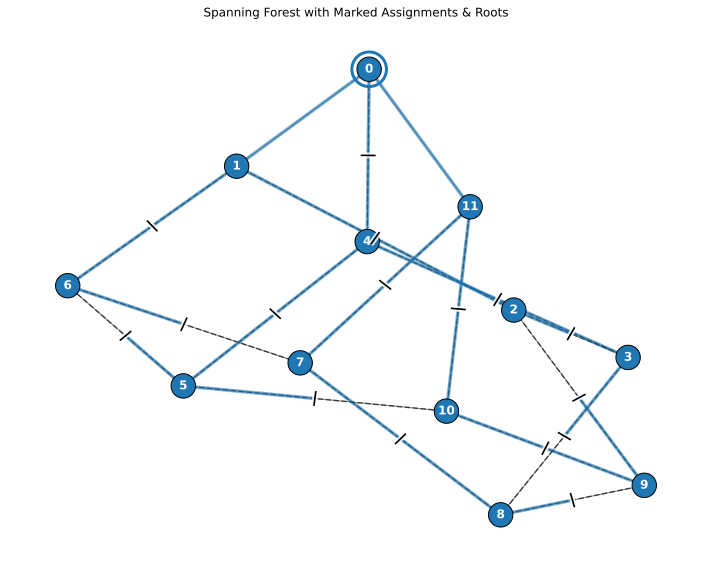

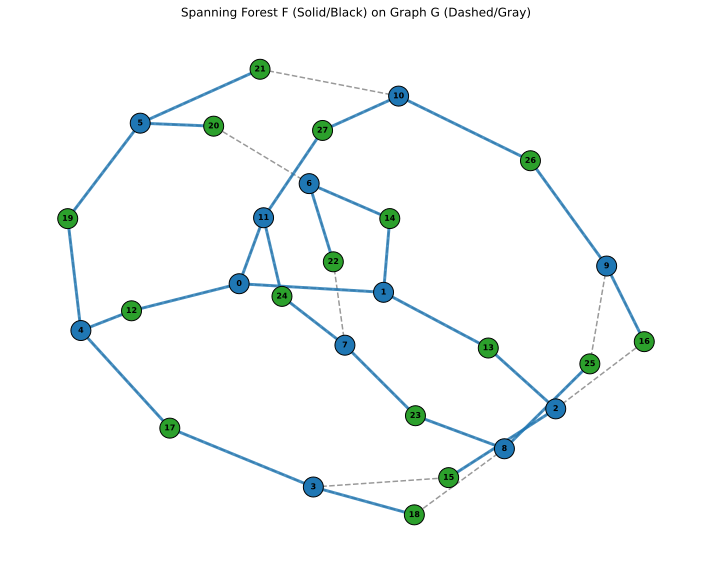

In [40]:
N, t = 16, 3
grf, _, M, _ = load_solution_triplet(N, t, 1)
tree, center, radius = find_mdst(grf)
print(f"Absolute Center: {center}")

matchings = match_forest_leaves_to_marked_edges(grf, tree, M)
print(f"M: {M}")
print(f"Matchings: {matchings}")
draw_spanning_forest_solution(grf, tree, M, matchings, {0: center[0] if isinstance(center, tuple) else center}, figsize=(10, 8))
G, F = expand_graph_and_forest(grf, tree, M, matchings)

draw_forest_on_graph(G, F)


Optimization finished in 1838 steps. Best Diameter: 11


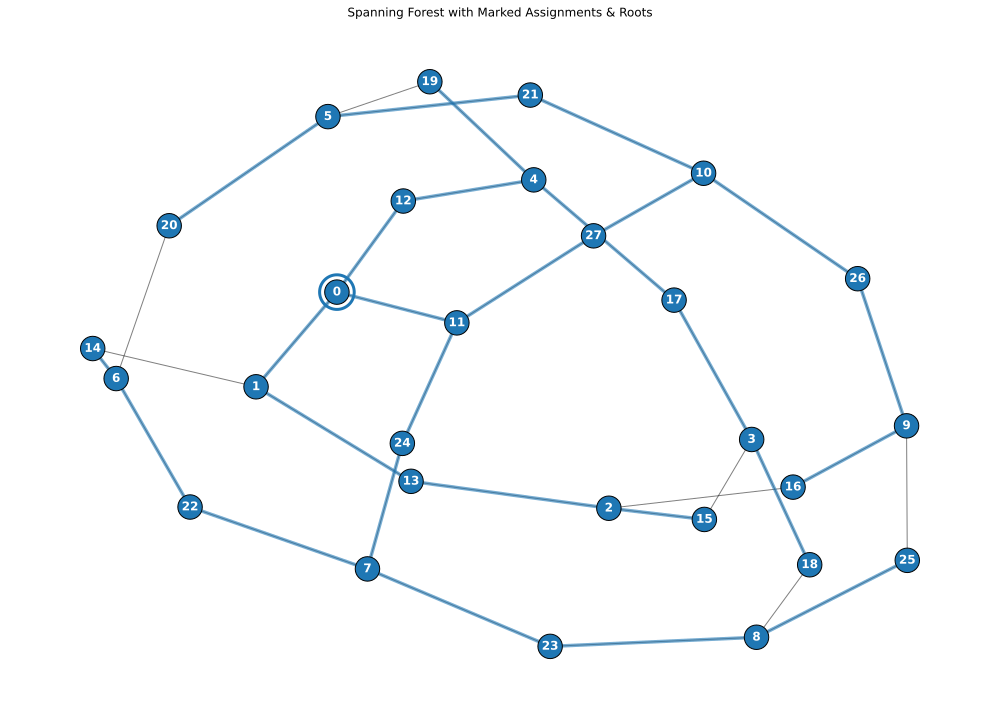

In [41]:
G_alt, _ = expand_graph_and_forest(grf, tree, M, matchings, expand_flags=False)
F_alt = constrained_mdsf_generation(G_alt, 1, seed=9001)
roots = find_min_height_degree_3_roots(F_alt)
draw_spanning_forest_solution(G_alt, F_alt, {}, {}, roots)

=== Starting Elegant Extraction (BFS) ===
Init Root 0 (Tree 0) -> Q0
  Node 0 -> Branch 11: Spawned CNOT Q0 -> Q1
  Node 0 -> Branch 1: Spawned CNOT Q0 -> Q2
  Node 0 -> Primary 12 (Inherits Q0)
  Node 11 -> Branch 24: Spawned CNOT Q1 -> Q3
  Node 11 -> Primary 27 (Inherits Q1)
  New flag initialised (1, 14): CNOT Q2 -> Q16
  Node 1 -> Primary 13 (Inherits Q2)
  Mark on 12: Spawned CNOT Q0 -> Q4
  Node 12 -> Primary 4 (Inherits Q0)
  Mark on 24: Spawned CNOT Q3 -> Q5
  Node 24 -> Primary 7 (Inherits Q3)
  Mark on 27: Spawned CNOT Q1 -> Q6
  Node 27 -> Primary 10 (Inherits Q1)
  Mark on 13: Spawned CNOT Q2 -> Q7
  Node 13 -> Primary 2 (Inherits Q2)
  Node 4 -> Branch 17: Spawned CNOT Q0 -> Q8
  Node 4 -> Primary 19 (Inherits Q0)
  Node 7 -> Branch 22: Spawned CNOT Q3 -> Q9
  Node 7 -> Primary 23 (Inherits Q3)
  Node 10 -> Branch 21: Spawned CNOT Q1 -> Q10
  Node 10 -> Primary 26 (Inherits Q1)
  New flag initialised (2, 16): CNOT Q2 -> Q17
  Node 2 -> Primary 15 (Inherits Q2)
  Mark on 1

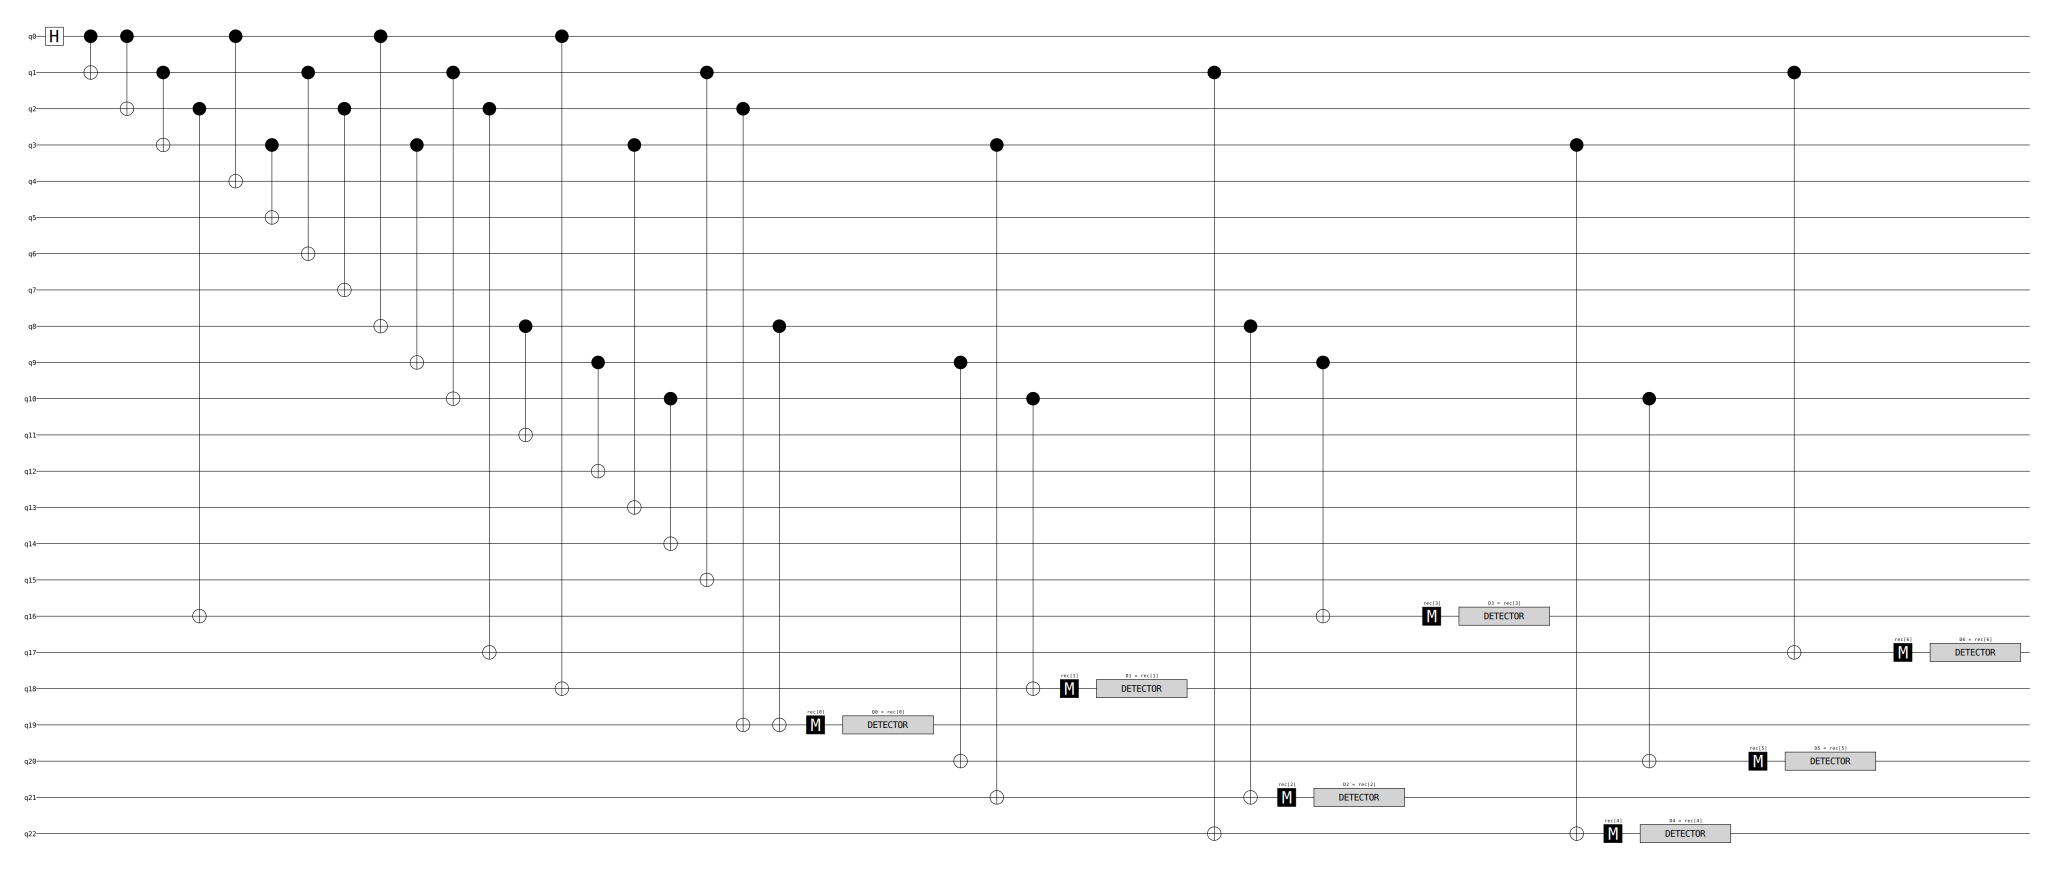

In [42]:
circ = extract_from_expanded_graph(G_alt, F_alt, roots, verbose=True)
circ.diagram('timeline-svg')

In [43]:
circ.append("M", range(N))
circ.compile_sampler().sample(10)[:,-N:]

array([[False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True],
       [False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  Tru

<Figure size 1000x800 with 0 Axes>

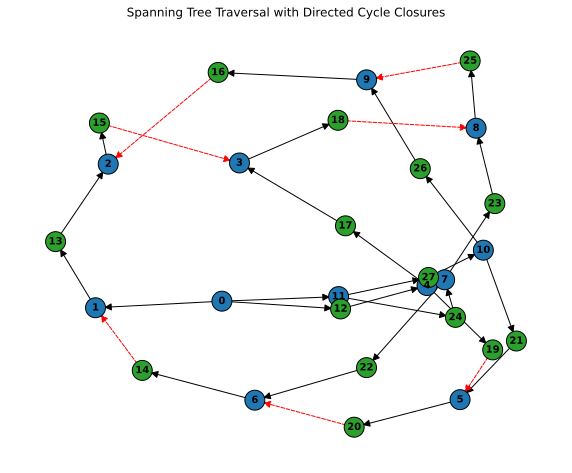

In [44]:
D = build_traversal_digraph(G_alt, F_alt, roots[0])
display_digraph(D)

(15, 3)


<Figure size 1000x800 with 0 Axes>

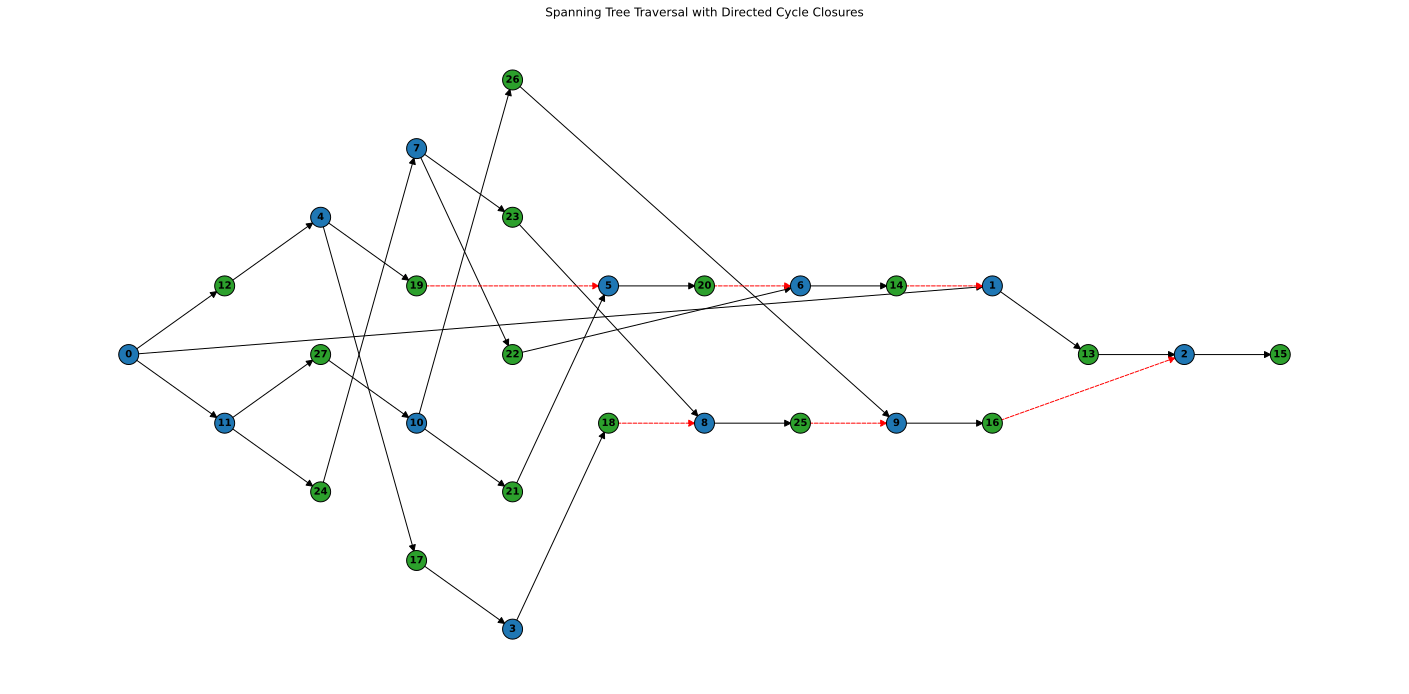

In [45]:
from spidercat.circuit_extraction import resolve_dag_by_removing_missing_link
import networkx as nx


_, edge, dependency_graph = resolve_dag_by_removing_missing_link(D)
print(edge[0])
display_digraph(dependency_graph)

=== Starting Elegant Extraction (BFS) ===
Init Root 0 (Tree 0) -> Q0
  Node 0 -> Branch 11: Spawned CNOT Q0 -> Q1
  Node 0 -> Branch 1: Spawned CNOT Q0 -> Q2
  Node 0 -> Primary 12 (Inherits Q0)
  Node 11 -> Branch 24: Spawned CNOT Q1 -> Q3
  Node 11 -> Primary 27 (Inherits Q1)
  Mark on 12: Spawned CNOT Q0 -> Q4
  Node 12 -> Primary 4 (Inherits Q0)
  Mark on 24: Spawned CNOT Q3 -> Q5
  Node 24 -> Primary 7 (Inherits Q3)
  Mark on 27: Spawned CNOT Q1 -> Q6
  Node 27 -> Primary 10 (Inherits Q1)
  Node 4 -> Branch 17: Spawned CNOT Q0 -> Q7
  Node 4 -> Primary 19 (Inherits Q0)
  Node 7 -> Branch 22: Spawned CNOT Q3 -> Q8
  Node 7 -> Primary 23 (Inherits Q3)
  Node 10 -> Branch 21: Spawned CNOT Q1 -> Q9
  Node 10 -> Primary 26 (Inherits Q1)
  Mark on 17: Spawned CNOT Q7 -> Q10
  Node 17 -> Primary 3 (Inherits Q7)
  New flag initialised (19, 5): CNOT Q0 -> Q16
  Node 19 serves as a sink point for Q0
  Mark on 22: Spawned CNOT Q8 -> Q11
  Node 22 -> Primary 6 (Inherits Q8)
  Mark on 23: Spaw

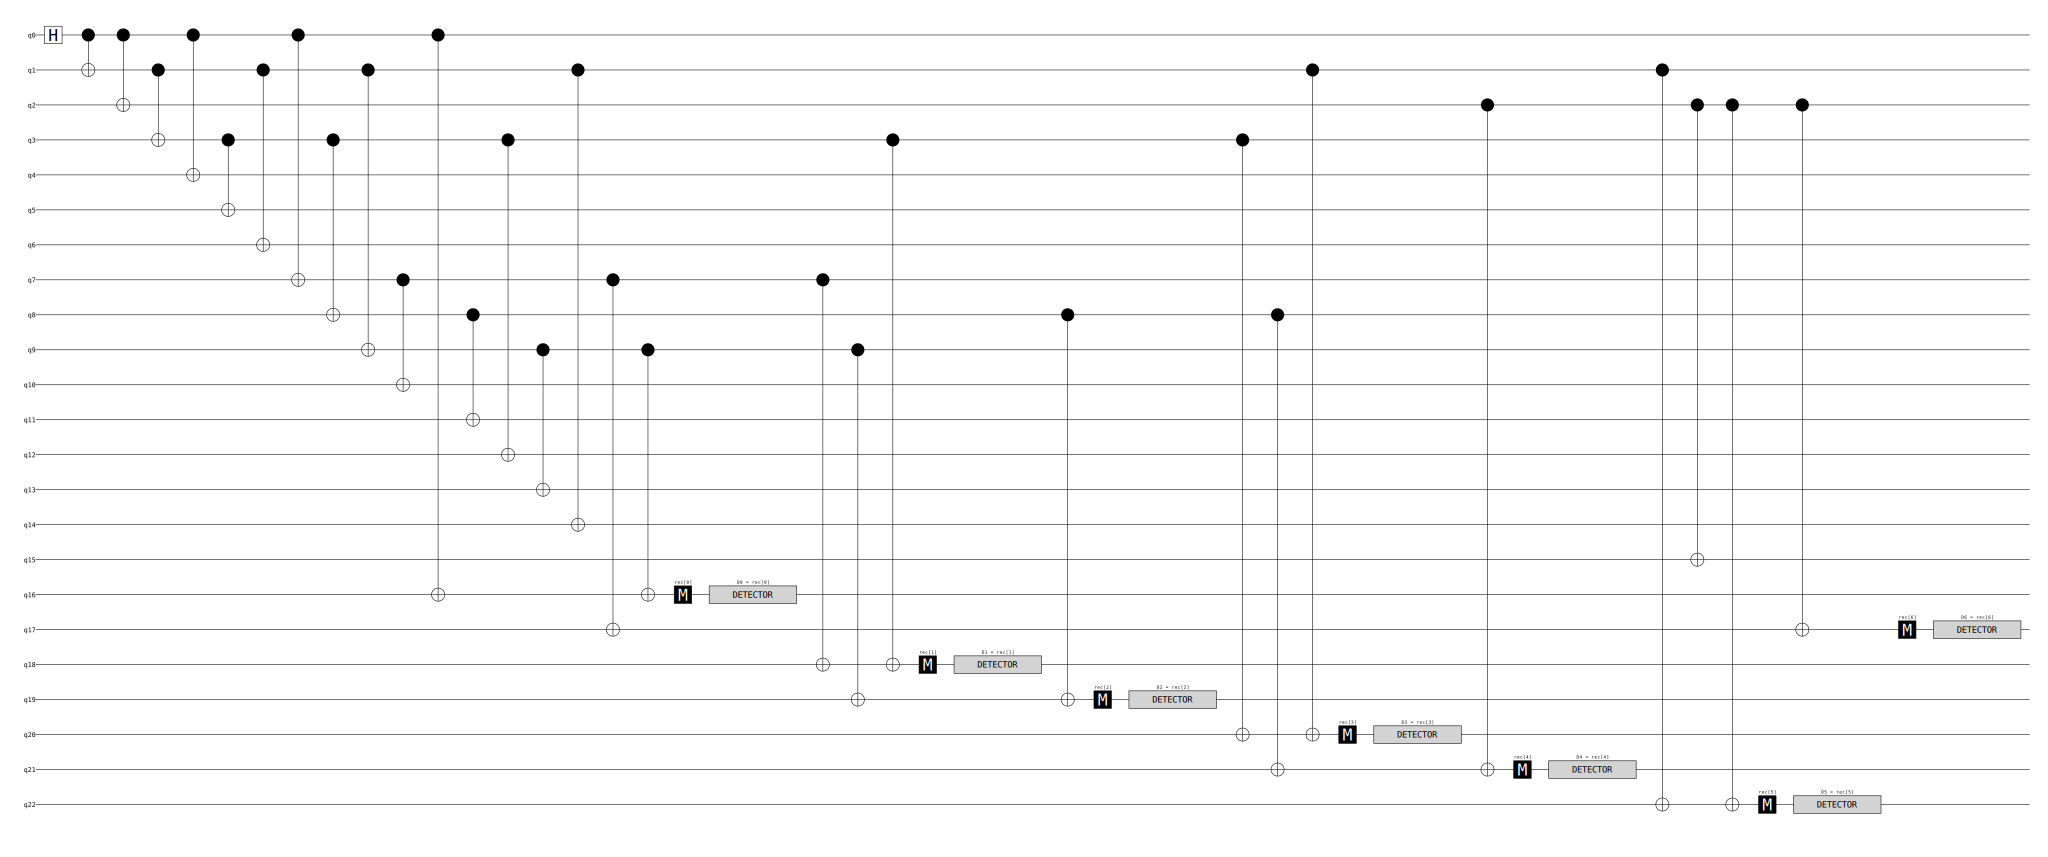

In [14]:
circ = extract_from_expanded_graph(G_alt, F_alt, roots, dependency_graph, verbose=True)
circ.diagram('timeline-svg')

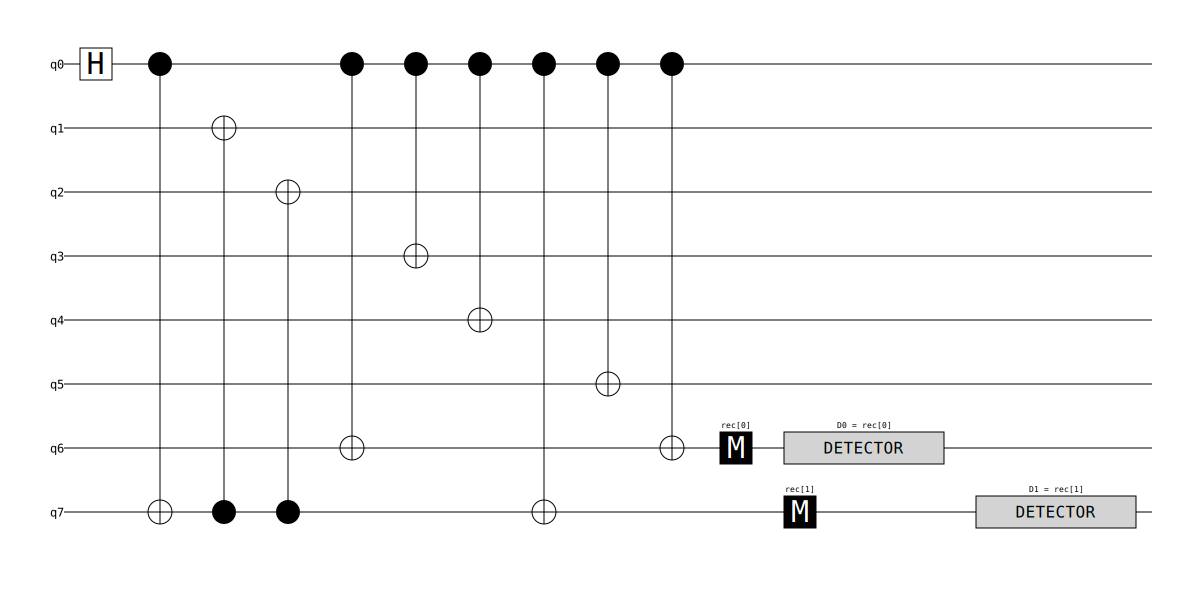

In [19]:
import stim

stim.Circuit("""
H 0
CX 0 7 7 1 7 2 0 6 0 3 0 4 0 7 0 5 0 6
M 6
DETECTOR rec[-1]
M 7
DETECTOR rec[-1]
""").diagram('timeline-svg')